In [1]:
import json
import random
from pathlib import Path
from typing import Any

from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoTokenizer

hf_token =json.load(open(Path("./config.json")))["hg_access_token"]
cache_dir =json.load(open(Path("./config.json")))["cache_dir"]
dataset_path=json.load(open(Path("./config.json")))["dataset_path"]

/home/erfan/miniconda3/envs/hf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# ============================================================
# Configuration
# ============================================================

OUTPUT_PATH = Path("./dataset/huggingface/qwen3_tool_calling")
MODEL_NAME = "Qwen/Qwen3-0.6B"

TEST_SIZE = 0.10
SEED = 42

# Set this to the key identifying paraphrases of the same example.
# Example:
# metadata = {"canonical_id": "fundamentals_000123"}
GROUP_KEY = "canonical_id"


SYSTEM_PROMPT = """
You are a financial function-calling model.
The user gives you names of companiesn, some feature and periods of time. You must convert the user's request into exactly one valid JSON object.

Supported function:
- get_fundamentals

Rules:

- Preserve the association between companies and their requested metrics.
- Do not answer the financial question yourself, analysis, speculations, or hypothetical questpions.
- Do not calculate or invent financial values.
- Do not generate SQL.
- Output only valid JSON.
""".strip()



In [3]:

# ============================================================
# Load tokenizer
# ============================================================



tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=hf_token, cache_dir=cache_dir)


# ============================================================
# Load JSONL
# ============================================================


raw_dataset = load_dataset(
    "json",
    data_files=str(dataset_path),
    split="train",
)

required_columns = {
    "query",
    "output_str",
    "output_json",
    "metadata",
}

missing_columns = required_columns - set(raw_dataset.column_names)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

raw_dataset[0]


{'query': 'For Broadcom, extract the net income and diluted shares from the financial records spanning from 2006 to 2018. For Apartment Investment and Manage, retrieve the revenue and free cash flow during the same time period—2006 through 2018—ensuring each metric is specifically tied to its respective company.',
 'output_str': '{"action": "call", "function": "get_fundamentals", "arguments": {"queries": [{"symbols": ["Broadcom"], "metrics": ["Net Income", "Diluted Shares"], "start_year": 2006, "end_year": 2018}, {"symbols": ["Apartment Investment and Manage"], "metrics": ["Free Cash Flow", "Revenue"], "start_year": 2006, "end_year": 2018}]}}',
 'output_json': {'action': 'call',
  'function': 'get_fundamentals',
  'arguments': {'queries': [{'symbols': ['Broadcom'],
     'metrics': ['Net Income', 'Diluted Shares'],
     'start_year': 2006,
     'end_year': 2018},
    {'symbols': ['Apartment Investment and Manage'],
     'metrics': ['Free Cash Flow', 'Revenue'],
     'start_year': 2006,


In [4]:

# ============================================================
# JSON validation and normalization
# ============================================================

def parse_json_value(value: Any) -> dict:
    """
    Convert either a JSON string or Python dictionary into a dictionary.
    """
    if isinstance(value, dict):
        return value

    if isinstance(value, str):
        parsed = json.loads(value)

        if not isinstance(parsed, dict):
            raise ValueError("Tool-call output must be a JSON object.")

        return parsed

    raise TypeError(
        f"Expected output to be dict or JSON string, got {type(value).__name__}"
    )


def validate_example(example: dict, index: int) -> dict:
    query = example["query"]

    if not isinstance(query, str) or not query.strip():
        raise ValueError(f"Example {index}: query is empty or invalid.")

    try:
        output_from_str = parse_json_value(example["output_str"])
    except Exception as exc:
        raise ValueError(
            f"Example {index}: invalid output_str: {exc}"
        ) from exc

    try:
        output_from_json = parse_json_value(example["output_json"])
    except Exception as exc:
        raise ValueError(
            f"Example {index}: invalid output_json: {exc}"
        ) from exc

    # Ensure that output_str and output_json represent the same object.
    if output_from_str != output_from_json:
        raise ValueError(
            f"Example {index}: output_str and output_json do not match.\n"
            f"output_str: {output_from_str}\n"
            f"output_json: {output_from_json}"
        )

    # Compact deterministic JSON target.
    normalized_output = json.dumps(
        output_from_json,
        ensure_ascii=False,
        separators=(",", ":"),
        sort_keys=False,
    )

    metadata = example["metadata"]

    if metadata is None:
        metadata = {}

    if not isinstance(metadata, dict):
        raise TypeError(
            f"Example {index}: metadata must be a dictionary."
        )

    return {
        "query": query.strip(),
        "completion": normalized_output,
        "metadata": metadata,
        "source_index": index,
    }


validated_dataset = raw_dataset.map(
    validate_example,
    with_indices=True,
    remove_columns=raw_dataset.column_names,
    desc="Validating examples",
)
validated_dataset



Dataset({
    features: ['query', 'metadata', 'completion', 'source_index'],
    num_rows: 3098
})

In [5]:
validated_dataset[0]

{'query': 'For Broadcom, extract the net income and diluted shares from the financial records spanning from 2006 to 2018. For Apartment Investment and Manage, retrieve the revenue and free cash flow during the same time period—2006 through 2018—ensuring each metric is specifically tied to its respective company.',
 'metadata': {'iteration': 211,
  'companies': ['Broadcom', 'Apartment Investment and Manage'],
  'symbols': ['AVGO', 'AIV'],
  'features': ['Net Income', 'Diluted Shares', 'Free Cash Flow', 'Revenue'],
  'metrics': ['netIncome', 'diluted_shares', 'fcf', 'totalRevenue'],
  'start_year': 2006,
  'end_year': 2018,
  'raw_model_output': 'Q1:  \nFor Broadcom, extract the net income and diluted shares from the financial records spanning from 2006 to 2018. For Apartment Investment and Manage, retrieve the revenue and free cash flow during the same time period—2006 through 2018—ensuring each metric is specifically tied to its respective company.\n\nQ2:  \nWhat data exists for Broadc

In [6]:

# ============================================================
# Split without leaking paraphrases
# ============================================================

def group_train_test_split(
    dataset: Dataset,
    group_key: str,
    test_size: float,
    seed: int,
) -> DatasetDict:
    """
    Split by metadata[group_key].

    All examples with the same canonical ID remain in the same split.
    If the group key is unavailable, each row becomes its own group.
    """
    groups: dict[str, list[int]] = {}

    for row_index, example in enumerate(dataset):
        metadata = example.get("metadata") or {}
        group_id = metadata.get(group_key)

        if group_id is None:
            # This row becomes an independent group.
            group_id = f"row_{example['source_index']}"

        group_id = str(group_id)
        groups.setdefault(group_id, []).append(row_index)

    group_ids = list(groups.keys())

    if len(group_ids) < 2:
        raise ValueError(
            "At least two distinct groups are required for train/test splitting."
        )

    rng = random.Random(seed)
    rng.shuffle(group_ids)

    number_of_test_groups = max(
        1,
        round(len(group_ids) * test_size),
    )

    # Ensure that at least one group remains in training.
    number_of_test_groups = min(
        number_of_test_groups,
        len(group_ids) - 1,
    )

    test_group_ids = set(group_ids[:number_of_test_groups])

    train_indices: list[int] = []
    test_indices: list[int] = []

    for group_id, indices in groups.items():
        if group_id in test_group_ids:
            test_indices.extend(indices)
        else:
            train_indices.extend(indices)

    return DatasetDict(
        {
            "train": dataset.select(train_indices),
            "test": dataset.select(test_indices),
        }
    )


dataset_splits = group_train_test_split(
    dataset=validated_dataset,
    group_key=GROUP_KEY,
    test_size=TEST_SIZE,
    seed=SEED,
)


In [7]:
dataset_splits

DatasetDict({
    train: Dataset({
        features: ['query', 'metadata', 'completion', 'source_index'],
        num_rows: 2788
    })
    test: Dataset({
        features: ['query', 'metadata', 'completion', 'source_index'],
        num_rows: 310
    })
})

In [ ]:


# ============================================================
# Build Qwen conversation format
# ============================================================

def build_training_example(example: dict) -> dict:
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": example["query"],
        },
        {
            "role": "assistant",
            "content": example["completion"],
        },
    ]

    # Fully formatted text for trainers expecting a `text` column.
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=False,
    )

    return {
        "messages": messages,
        "text": text,
    }


dataset_splits = dataset_splits.map(
    build_training_example,
    desc="Applying Qwen chat template",
)


# Keep useful columns.
dataset_splits = DatasetDict(
    {
        split_name: split_dataset.select_columns(
            [
                "messages",
                "text",
                "query",
                "completion",
                "metadata",
                "source_index",
            ]
        )
        for split_name, split_dataset in dataset_splits.items()
    }
)


# ============================================================
# Save dataset
# ============================================================

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

dataset_splits.save_to_disk(str(OUTPUT_PATH))


# ============================================================
# Inspection
# ============================================================

print(dataset_splits)

print("\nTrain size:", len(dataset_splits["train"]))
print("Test size:", len(dataset_splits["test"]))

print("\nMessages representation:")
print(
    json.dumps(
        dataset_splits["train"][0]["messages"],
        indent=2,
        ensure_ascii=False,
    )
)

print("\nFormatted training text:")
print(dataset_splits["train"][0]["text"])

Saving the dataset (1/1 shards): 100%|██████████| 310/310 [00:00<00:00, 136823.55 examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages', 'text', 'query', 'completion', 'metadata', 'source_index'],
        num_rows: 2788
    })
    test: Dataset({
        features: ['messages', 'text', 'query', 'completion', 'metadata', 'source_index'],
        num_rows: 310
    })
})

Train size: 2788
Test size: 310

Messages representation:
[
  {
    "role": "system",
    "content": "You are a financial function-calling model.\nThe user gives you names of companiesn, some feature and periods of time. You must convert the user's request into exactly one valid JSON object.\n\nSupported function:\n- get_fundamentals\n\nRules:\n\n- Preserve the association between companies and their requested metrics.\n- Do not answer the financial question yourself, analysis, speculations, or hypothetical questpions.\n- Do not calculate or invent financial values.\n- Do not generate SQL.\n- Output only valid JSON."
  },
  {
    "role": "user",
    "content": "What data exists for Broadcom 

In [9]:
for i in range(3):
    print(dataset_splits['train']['messages'][i])
    print(len(tokenizer.apply_chat_template(dataset_splits['train']['messages'][i])['input_ids']))

[{'role': 'system', 'content': "You are a financial function-calling model.\nThe user gives you names of companiesn, some feature and periods of time. You must convert the user's request into exactly one valid JSON object.\n\nSupported function:\n- get_fundamentals\n\nRules:\n\n- Preserve the association between companies and their requested metrics.\n- Do not answer the financial question yourself, analysis, speculations, or hypothetical questpions.\n- Do not calculate or invent financial values.\n- Do not generate SQL.\n- Output only valid JSON."}, {'role': 'user', 'content': 'What data exists for Broadcom in terms of net income and diluted shares between 2006 and 2018? And separately, what revenue and free cash flow figures are recorded for Apartment Investment and Manage over the identical timeframe? Keep the company-specific assignments clear and include all values from the defined years.'}, {'role': 'assistant', 'content': '{"action":"call","function":"get_fundamentals","argument

In [10]:
lengths = [
    len(tokenizer.apply_chat_template(
        example["messages"],
        tokenize=True,
        add_generation_prompt=False,
    )['input_ids'])
    for example in dataset_splits["train"]
]

In [11]:
from statistics import mean 

print(mean(lengths))
print(max(lengths))
min(lengths)

232.4167862266858
307


176

In [12]:
# ============================================================
# LoRA fine-tuning configuration
# ============================================================

import inspect

import matplotlib.pyplot as plt
import torch
from peft import LoraConfig, get_peft_model
from transformers import (
    AutoModelForCausalLM,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)


FINETUNED_MODEL_PATH = Path("./models/qwen3_0_6b_tool_calling_lora")

MAX_LENGTH = 384

NUM_TRAIN_EPOCHS = 3

PER_DEVICE_TRAIN_BATCH_SIZE = 8
PER_DEVICE_EVAL_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 2

LEARNING_RATE = 1e-4
WARMUP_STEPS = 243
WEIGHT_DECAY = 0.01

LOGGING_STEPS = 10
EVAL_STEPS = 250
SAVE_STEPS = 250
SAVE_TOTAL_LIMIT = 2


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

use_cuda = torch.cuda.is_available()
use_bf16 = use_cuda and torch.cuda.is_bf16_supported()
model_dtype = torch.bfloat16 if use_bf16 else torch.float16 if use_cuda else torch.float32

print("CUDA available:", use_cuda)
print("Model dtype:", model_dtype)


CUDA available: False
Model dtype: torch.float32


In [13]:
# ============================================================
# Tokenize and mask prompt tokens
# ============================================================

def build_prompt_text(example: dict) -> str:
    prompt_messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": example["query"],
        },
    ]

    return tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )


def tokenize_training_example(example: dict) -> dict:
    full_text = example["text"]
    prompt_text = build_prompt_text(example)

    tokenized_full = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    )
    tokenized_prompt = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    )

    labels = tokenized_full["input_ids"].copy()
    prompt_length = min(
        len(tokenized_prompt["input_ids"]),
        len(labels),
    )
    labels[:prompt_length] = [-100] * prompt_length

    return {
        "input_ids": tokenized_full["input_ids"],
        "attention_mask": tokenized_full["attention_mask"],
        "labels": labels,
    }


tokenized_splits = dataset_splits.map(
    tokenize_training_example,
    remove_columns=dataset_splits["train"].column_names,
    desc="Tokenizing for LoRA training",
)

tokenized_splits


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2788
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 310
    })
})

In [14]:
# ============================================================
# Load model and attach LoRA adapters
# ============================================================

model_kwargs = {
    "token": hf_token,
    "cache_dir": cache_dir,
    "torch_dtype": model_dtype,
}

if use_cuda:
    model_kwargs["device_map"] = "auto"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    **model_kwargs,
)
model.config.use_cache = False
model.gradient_checkpointing_enable()

if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.00,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "v_proj",

    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 3042.78it/s]


trainable params: 1,146,880 || all params: 597,196,800 || trainable%: 0.1920


In [15]:
# ============================================================
# Train LoRA adapters
# ============================================================

training_args_kwargs = {
    "output_dir": str(FINETUNED_MODEL_PATH),
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "warmup_steps": WARMUP_STEPS,
    "weight_decay": WEIGHT_DECAY,
    "lr_scheduler_type": "cosine",
    "logging_steps": LOGGING_STEPS,
    "eval_steps": EVAL_STEPS,
    "save_steps": SAVE_STEPS,
    "save_total_limit": 2,
    "gradient_checkpointing": False,
    "bf16": use_bf16,
    "fp16": use_cuda and not use_bf16,
    "optim": "adamw_torch",
    "report_to": "none",
    "remove_unused_columns": False,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
}

training_args_signature = inspect.signature(TrainingArguments.__init__).parameters

if "eval_strategy" in training_args_signature:
    training_args_kwargs["eval_strategy"] = "steps"
else:
    training_args_kwargs["evaluation_strategy"] = "steps"

training_args = TrainingArguments(**training_args_kwargs)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8 if use_cuda else None,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_splits["train"],
    eval_dataset=tokenized_splits["test"],
    data_collator=data_collator,
    processing_class=tokenizer,
)

train_result = trainer.train()

trainer.save_model(str(FINETUNED_MODEL_PATH))
tokenizer.save_pretrained(str(FINETUNED_MODEL_PATH))
trainer.save_state()

train_result.metrics


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/home/erfan/miniconda3/envs/hf/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss
250,0.025075,0.024831
500,0.018651,0.017704
525,0.018307,0.017718


/home/erfan/miniconda3/envs/hf/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/erfan/miniconda3/envs/hf/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'train_runtime': 19505.0387,
 'train_samples_per_second': 0.429,
 'train_steps_per_second': 0.027,
 'total_flos': 5866616814305280.0,
 'train_loss': 0.1292265226869356,
 'epoch': 3.0}

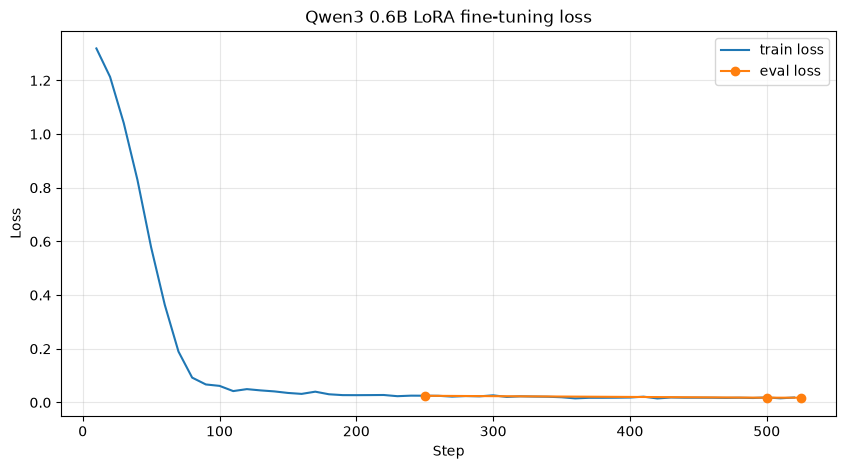

In [16]:
# ============================================================
# Loss graphs
# ============================================================

train_loss = [
    (entry["step"], entry["loss"])
    for entry in trainer.state.log_history
    if "loss" in entry and "step" in entry
]
eval_loss = [
    (entry["step"], entry["eval_loss"])
    for entry in trainer.state.log_history
    if "eval_loss" in entry and "step" in entry
]

plt.figure(figsize=(10, 5))

if train_loss:
    train_steps, train_values = zip(*train_loss)
    plt.plot(train_steps, train_values, label="train loss")

if eval_loss:
    eval_steps, eval_values = zip(*eval_loss)
    plt.plot(eval_steps, eval_values, marker="o", label="eval loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Qwen3 0.6B LoRA fine-tuning loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
